# Decision Tree Classification

Notebook praktikum Week 12 untuk memahami **Decision Tree Classification** menggunakan dataset pembelajaran, bukan dataset kompetisi Kaggle.

Dataset utama: **Breast Cancer Wisconsin (Diagnostic)** dari `sklearn.datasets`.

Fokus praktikum:
1. Memahami cara Decision Tree melakukan split.
2. Melihat overfitting pada tree yang terlalu dalam.
3. Mengontrol kompleksitas model dengan pruning parameter.
4. Mengevaluasi model dengan ROC-AUC, confusion matrix, dan classification report.
5. Menginterpretasikan model melalui feature importance dan decision rules.

## 1. Import Library

Library yang digunakan: `pandas`, `numpy`, `matplotlib`, dan `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Load Dataset

Dataset Breast Cancer Wisconsin berisi fitur numerik dari citra sel hasil pemeriksaan FNA (*fine needle aspirate*).

Target asli scikit-learn:
- `0`: malignant
- `1`: benign

Agar kelas positif lebih natural untuk evaluasi, target diubah menjadi:
- `1`: malignant
- `0`: benign

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y_original = data.target.copy()

# Original sklearn: 0 = malignant, 1 = benign
# Praktikum: 1 = malignant, 0 = benign
y = (y_original == 0).astype(int)
y.name = "is_malignant"

df = X.copy()
df[y.name] = y

display(df.head())
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah fitur: {X.shape[1]}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is_malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


Jumlah baris: 569
Jumlah fitur: 30


## 3. Data Understanding Singkat

Dataset ini sudah bersih dan semua fitur numerik. Kita cukup cek distribusi target dan statistik fitur.

In [3]:
target_counts = y.value_counts().sort_index()
target_percent = y.value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2),
})
target_summary.index = ["benign (0)", "malignant (1)"]

display(target_summary)

,count,percentage
benign (0),357,62.74
malignant (1),212,37.26


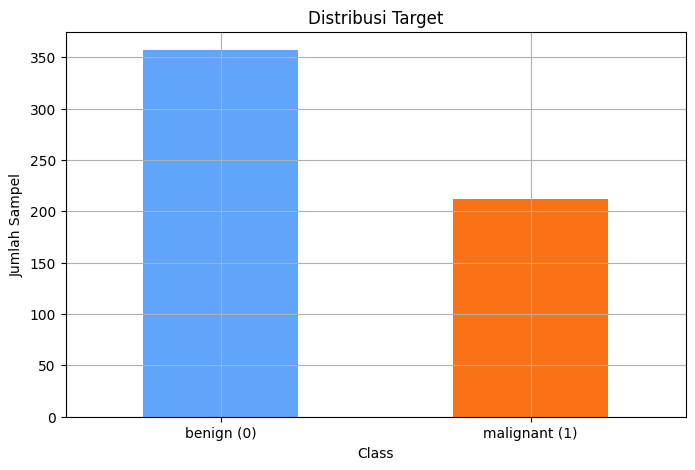

In [4]:
ax = target_counts.plot(kind="bar", color=["#60A5FA", "#F97316"])
ax.set_title("Distribusi Target")
ax.set_xlabel("Class")
ax.set_ylabel("Jumlah Sampel")
ax.set_xticklabels(["benign (0)", "malignant (1)"], rotation=0)
plt.show()

In [5]:
summary = X.describe().T[["mean", "std", "min", "max"]]
display(summary.head(10))

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


## 4. Train/Validation Split

Kita memakai stratified split agar proporsi class pada train dan validation tetap mirip.

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Train target rate (malignant):", round(y_train.mean(), 3))
print("Valid target rate (malignant):", round(y_valid.mean(), 3))

Train shape: (426, 30)
Valid shape: (143, 30)
Train target rate (malignant): 0.373
Valid target rate (malignant): 0.371


## 5. Baseline: Decision Tree Tanpa Pembatasan

Pertama, kita latih tree tanpa batas kedalaman. Ekspektasinya: training score sangat tinggi dan validation score bisa lebih rendah.

In [7]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)

baseline_train_proba = baseline_tree.predict_proba(X_train)[:, 1]
baseline_valid_proba = baseline_tree.predict_proba(X_valid)[:, 1]

baseline_train_auc = roc_auc_score(y_train, baseline_train_proba)
baseline_valid_auc = roc_auc_score(y_valid, baseline_valid_proba)

print("Baseline tree depth:", baseline_tree.get_depth())
print("Baseline number of leaves:", baseline_tree.get_n_leaves())
print("Train ROC-AUC:", round(baseline_train_auc, 4))
print("Valid ROC-AUC:", round(baseline_valid_auc, 4))

Baseline tree depth: 8
Baseline number of leaves: 21
Train ROC-AUC: 1.0
Valid ROC-AUC: 0.9473


### Interpretasi Baseline

Jika train ROC-AUC jauh lebih tinggi dibanding validation ROC-AUC, model kemungkinan terlalu mengikuti detail training data.

## 6. Model dengan Pre-pruning

Pre-pruning berarti membatasi pertumbuhan tree sejak awal. Parameter penting: `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

In [8]:
pruned_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)
pruned_tree.fit(X_train, y_train)

pruned_train_proba = pruned_tree.predict_proba(X_train)[:, 1]
pruned_valid_proba = pruned_tree.predict_proba(X_valid)[:, 1]

pruned_train_auc = roc_auc_score(y_train, pruned_train_proba)
pruned_valid_auc = roc_auc_score(y_valid, pruned_valid_proba)

print("Pruned tree depth:", pruned_tree.get_depth())
print("Pruned number of leaves:", pruned_tree.get_n_leaves())
print("Train ROC-AUC:", round(pruned_train_auc, 4))
print("Valid ROC-AUC:", round(pruned_valid_auc, 4))

Pruned tree depth: 4
Pruned number of leaves: 7
Train ROC-AUC: 0.9873
Valid ROC-AUC: 0.9581


In [9]:
comparison = pd.DataFrame({
    "model": ["Baseline tree", "Pre-pruned tree"],
    "depth": [baseline_tree.get_depth(), pruned_tree.get_depth()],
    "n_leaves": [baseline_tree.get_n_leaves(), pruned_tree.get_n_leaves()],
    "train_auc": [baseline_train_auc, pruned_train_auc],
    "valid_auc": [baseline_valid_auc, pruned_valid_auc],
})
comparison["gap_train_valid"] = comparison["train_auc"] - comparison["valid_auc"]
display(comparison.round(4))

,model,depth,n_leaves,train_auc,valid_auc,gap_train_valid
0,Baseline tree,8,21,1.0000,0.9473,0.0527
1,Pre-pruned tree,4,7,0.9873,0.9581,0.0292


## 7. Hyperparameter Tuning

Kita cari kombinasi parameter yang lebih baik menggunakan cross-validation di training set.

In [10]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))
print("Best parameters:")
for key, value in grid_search.best_params_.items():
    print(f"  {key}: {value}")

Best CV ROC-AUC: 0.9712
Best parameters:
  ccp_alpha: 0.0
  criterion: entropy
  max_depth: 4
  min_samples_leaf: 20
  min_samples_split: 2


In [11]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = [
    "mean_train_score", "mean_test_score", "param_criterion",
    "param_max_depth", "param_min_samples_split",
    "param_min_samples_leaf", "param_ccp_alpha",
]

top_results = cv_results[cols].sort_values("mean_test_score", ascending=False).head(10)
display(top_results.round(4))

,mean_train_score,mean_test_score,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_ccp_alpha
394,0.9876,0.9712,entropy,4,10,20,0.005
141,0.9876,0.9712,entropy,None,2,20,0.000
131,0.9876,0.9712,entropy,6,20,20,0.000
130,0.9876,0.9712,entropy,6,10,20,0.000
129,0.9876,0.9712,entropy,6,2,20,0.000
119,0.9876,0.9712,entropy,5,20,20,0.000
118,0.9876,0.9712,entropy,5,10,20,0.000
117,0.9876,0.9712,entropy,5,2,20,0.000
405,0.9876,0.9712,entropy,5,2,20,0.005
107,0.9876,0.9712,entropy,4,20,20,0.000


## 8. Evaluasi Model Hasil GridSearchCV pada Validation Set

`GridSearchCV` memilih parameter terbaik berdasarkan rata-rata skor cross-validation di training set.

Namun, model yang terbaik di cross-validation belum tentu menjadi model dengan skor tertinggi pada satu validation split. Karena itu, kita tetap bandingkan hasilnya dengan baseline dan manual pre-pruned tree.

In [12]:
cv_tree = grid_search.best_estimator_

cv_train_proba = cv_tree.predict_proba(X_train)[:, 1]
cv_valid_proba = cv_tree.predict_proba(X_valid)[:, 1]
cv_valid_pred = cv_tree.predict(X_valid)

cv_train_auc = roc_auc_score(y_train, cv_train_proba)
cv_valid_auc = roc_auc_score(y_valid, cv_valid_proba)

print("CV-selected tree depth:", cv_tree.get_depth())
print("CV-selected number of leaves:", cv_tree.get_n_leaves())
print("Train ROC-AUC:", round(cv_train_auc, 4))
print("Valid ROC-AUC:", round(cv_valid_auc, 4))
print("Gap train-valid:", round(cv_train_auc - cv_valid_auc, 4))

CV-selected tree depth: 4
CV-selected number of leaves: 6
Train ROC-AUC: 0.9868
Valid ROC-AUC: 0.9423
Gap train-valid: 0.0445


In [13]:
final_comparison = pd.DataFrame({
    "model": ["Baseline", "Manual pre-pruned", "GridSearchCV-selected"],
    "depth": [baseline_tree.get_depth(), pruned_tree.get_depth(), cv_tree.get_depth()],
    "n_leaves": [baseline_tree.get_n_leaves(), pruned_tree.get_n_leaves(), cv_tree.get_n_leaves()],
    "train_auc": [baseline_train_auc, pruned_train_auc, cv_train_auc],
    "valid_auc": [baseline_valid_auc, pruned_valid_auc, cv_valid_auc],
})
final_comparison["gap_train_valid"] = final_comparison["train_auc"] - final_comparison["valid_auc"]
display(final_comparison.round(4))

,model,depth,n_leaves,train_auc,valid_auc,gap_train_valid
0,Baseline,8,21,1.0000,0.9473,0.0527
1,Manual pre-pruned,4,7,0.9873,0.9581,0.0292
2,GridSearchCV-selected,4,6,0.9868,0.9423,0.0445


## 8.1 Final Model Selection

Dari tabel perbandingan, kita pilih model dengan **validation ROC-AUC tertinggi** sebagai final model untuk visualisasi dan interpretasi.

Catatan penting: `GridSearchCV` tetap berguna untuk tuning, tetapi hasilnya tetap perlu dicek pada validation set.

In [14]:
candidate_models = {
    "Baseline": baseline_tree,
    "Manual pre-pruned": pruned_tree,
    "GridSearchCV-selected": cv_tree,
}

selected_row = final_comparison.sort_values("valid_auc", ascending=False).iloc[0]
final_model_name = selected_row["model"]
final_tree = candidate_models[final_model_name]

final_train_proba = final_tree.predict_proba(X_train)[:, 1]
final_valid_proba = final_tree.predict_proba(X_valid)[:, 1]
final_valid_pred = final_tree.predict(X_valid)

print("Final selected model:", final_model_name)
print("Final tree depth:", final_tree.get_depth())
print("Final number of leaves:", final_tree.get_n_leaves())
print("Final valid ROC-AUC:", round(roc_auc_score(y_valid, final_valid_proba), 4))

Final selected model: Manual pre-pruned
Final tree depth: 4
Final number of leaves: 7
Final valid ROC-AUC: 0.9581


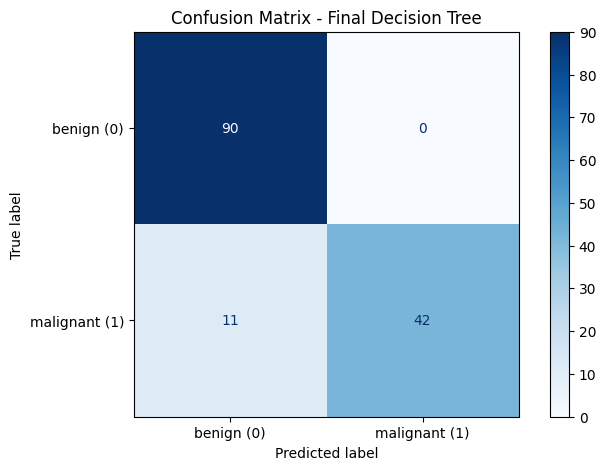

In [15]:
cm = confusion_matrix(y_valid, final_valid_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign (0)", "malignant (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Final Decision Tree")
plt.grid(False)
plt.show()

In [16]:
print(classification_report(y_valid, final_valid_pred, target_names=["benign", "malignant"]))

              precision    recall  f1-score   support

      benign       0.89      1.00      0.94        90
   malignant       1.00      0.79      0.88        53

    accuracy                           0.92       143
   macro avg       0.95      0.90      0.91       143
weighted avg       0.93      0.92      0.92       143



## 9. Visualisasi Decision Tree

Tree yang terlalu dalam sulit dibaca. Untuk visualisasi, tampilkan kedalaman terbatas agar aturan utama terlihat.

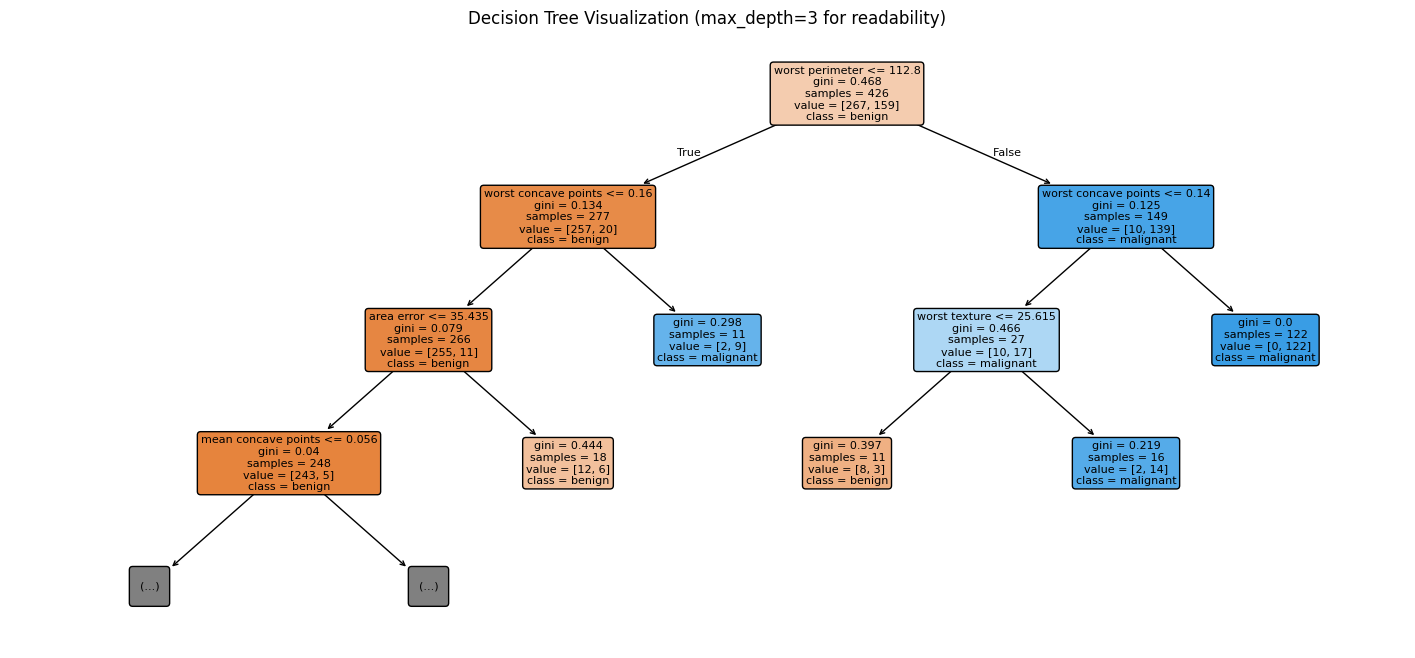

In [17]:
plt.figure(figsize=(18, 8))
plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=["benign", "malignant"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Visualization (max_depth=3 for readability)")
plt.show()

## 10. Feature Importance

Decision Tree menghitung feature importance berdasarkan total penurunan impurity yang disumbangkan oleh setiap fitur. Ini berguna sebagai interpretasi awal, bukan bukti kausalitas.

In [18]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_tree.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance.head(10))

,feature,importance
22,worst perimeter,0.834502
27,worst concave points,0.109380
21,worst texture,0.027493
13,area error,0.019138
7,mean concave points,0.009488
0,mean radius,0.000000
16,concavity error,0.000000
28,worst symmetry,0.000000
26,worst concavity,0.000000
25,worst compactness,0.000000


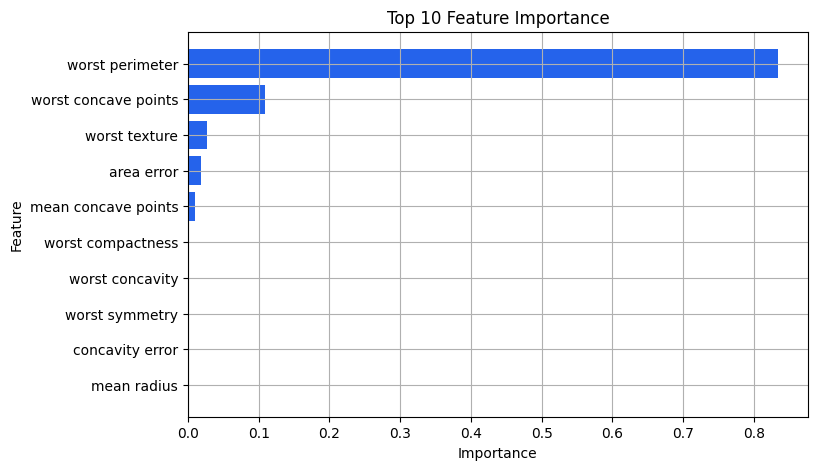

In [19]:
top_k = 10
plot_data = importance.head(top_k).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_data["feature"], plot_data["importance"], color="#2563EB")
plt.title(f"Top {top_k} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 11. Decision Rules

Selain plot tree, kita bisa mengekspor aturan tree dalam bentuk teks.

In [20]:
rules = export_text(final_tree, feature_names=list(X.columns), max_depth=3)
print(rules)

|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.16
|   |   |--- area error <= 35.44
|   |   |   |--- mean concave points <= 0.06
|   |   |   |   |--- class: 0
|   |   |   |--- mean concave points >  0.06
|   |   |   |   |--- class: 0
|   |   |--- area error >  35.44
|   |   |   |--- class: 0
|   |--- worst concave points >  0.16
|   |   |--- class: 1
|--- worst perimeter >  112.80
|   |--- worst concave points <= 0.14
|   |   |--- worst texture <= 25.61
|   |   |   |--- class: 0
|   |   |--- worst texture >  25.61
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- class: 1



## 12. Eksperimen Singkat: Efek `max_depth`

Kita bandingkan performa train dan validation untuk beberapa nilai `max_depth`.

In [21]:
depth_values = [1, 2, 3, 4, 5, 6, 8, 10, None]
records = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    records.append({
        "max_depth": "None" if depth is None else depth,
        "tree_depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
        "train_auc": train_auc,
        "valid_auc": valid_auc,
        "gap": train_auc - valid_auc,
    })

depth_results = pd.DataFrame(records)
display(depth_results.round(4))

,max_depth,tree_depth,n_leaves,train_auc,valid_auc,gap
0,1,1,2,0.9184,0.8568,0.0616
1,2,2,4,0.9524,0.8798,0.0727
2,3,3,7,0.9709,0.8441,0.1268
3,4,4,11,0.9879,0.9343,0.0536
4,5,5,14,0.9933,0.9541,0.0392
5,6,6,18,0.9970,0.8802,0.1169
6,8,8,21,1.0000,0.9473,0.0527
7,10,8,21,1.0000,0.9473,0.0527
8,None,8,21,1.0000,0.9473,0.0527


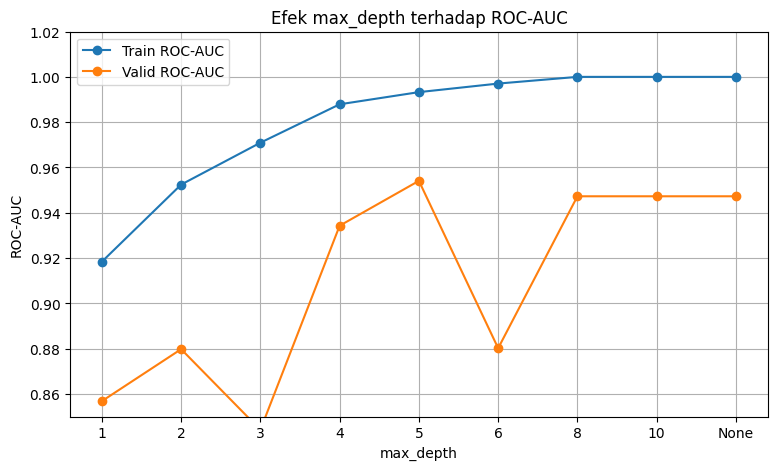

In [22]:
plot_df = depth_results.copy()
plot_df["max_depth_label"] = plot_df["max_depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(plot_df["max_depth_label"], plot_df["train_auc"], marker="o", label="Train ROC-AUC")
plt.plot(plot_df["max_depth_label"], plot_df["valid_auc"], marker="o", label="Valid ROC-AUC")
plt.title("Efek max_depth terhadap ROC-AUC")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.ylim(0.85, 1.02)
plt.legend()
plt.show()

## 13. Kesimpulan

Hal penting dari praktikum:

1. Decision Tree mudah diinterpretasikan karena prediksi mengikuti aturan split.
2. Tree tanpa pembatasan cenderung overfit.
3. Parameter seperti `max_depth`, `min_samples_leaf`, dan `ccp_alpha` membantu mengontrol kompleksitas.
4. Evaluasi perlu membandingkan performa train dan validation, bukan hanya training score.
5. Feature importance dan decision rules membantu menjelaskan model, tetapi tetap perlu hati-hati dalam interpretasi.